In [29]:
#!/usr/bin/env python
# coding: utf-8

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Masking, Bidirectional
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [30]:
MANIFEST_PATH = "Entropy_DTW_features/_manifest_entropy_dtw.csv"
BASE_DIR = r"D:\Infant Cry Vocalisation\Entropy_DTW_features"

df = pd.read_csv(MANIFEST_PATH)
print(f"Loaded {len(df)} samples")

Loaded 3300 samples


In [31]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["class"])

num_classes = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

Classes: ['belly pain' 'burping' 'cold_hot' 'discomfort' 'hungry' 'tired']


In [32]:
X, y = [], []

for _, row in df.iterrows():
    class_name = row["class"]
    file_name = os.path.basename(row["path"])
    feat_path = os.path.join(BASE_DIR, class_name, file_name)

    if not os.path.exists(feat_path):
        continue

    feat = np.load(feat_path)      # (features, time)
    feat = feat.T                  # (time, features)

    # Per-sample normalization (VERY important)
    feat = (feat - feat.mean(axis=0)) / (feat.std(axis=0) + 1e-8)

    X.append(feat)
    y.append(row["label"])

X = np.array(X, dtype=object)
y = np.array(y)


In [33]:
max_len = max(seq.shape[0] for seq in X)
num_features = X[0].shape[1]

X_padded = pad_sequences(
    X,
    maxlen=max_len,
    padding="post",
    dtype="float32",
    value=0.0
)

y_cat = to_categorical(y, num_classes)

print("Final input shape:", X_padded.shape)


Final input shape: (3300, 219, 18)


In [34]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_padded, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Train: (2640, 219, 18)
Val  : (330, 219, 18)
Test : (330, 219, 18)


In [35]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0)}


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_lstm_model(input_shape, num_classes, lr=1e-3):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=lr),
        metrics=['accuracy']
    )
    return model

model = build_lstm_model(X_train.shape[1:], num_classes)
model.summary()

c:\Users\91720\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 219, 128)       │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 219, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 219, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,990 (507.77 KB)

 Trainable params: 129,606 (506.27 KB)

 Non-trainable params: 384 (1.50 KB)

In [37]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=6,
        factor=0.5,
        min_lr=1e-5
    )
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 726ms/step - accuracy: 0.2068 - loss: 2.0163 - val_accuracy: 0.2121 - val_loss: 1.7693 - learning_rate: 0.0010
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 877ms/step - accuracy: 0.2307 - loss: 1.8210 - val_accuracy: 0.2515 - val_loss: 1.7553 - learning_rate: 0.0010
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 36s 850ms/step - accuracy: 0.2538 - loss: 1.7719 - val_accuracy: 0.2485 - val_loss: 1.7363 - learning_rate: 0.0010
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 45s 942ms/step - accuracy: 0.2678 - loss: 1.7258 - val_accuracy: 0.2364 - val_loss: 1.7403 - learning_rate: 0.0010
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 925ms/step - accuracy: 0.2780 - loss: 1.6869 - val_accuracy: 0.2121 - val_loss: 1.7468 - learning_rate: 0.0010
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 952ms/step - accuracy: 0.2811 - loss: 1.6711 - val_accuracy: 0.2273 - val_loss: 1.7323 - learning_rate: 0.0010
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 927ms/step - accuracy: 0.2932 - l

In [38]:
print("\n--- Train Evaluation ---")
train_loss, train_acc = model.evaluate(
    X_train, y_train_cat, verbose=0
)

print("\n--- Validation Evaluation ---")
val_loss, val_acc = model.evaluate(
    X_val, y_val_cat, verbose=0
)

print("\n--- Test Evaluation ---")
test_loss, test_acc = model.evaluate(
    X_test, y_test_cat, verbose=0
)

print("\n==============================")
print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
print(f"Val   Loss: {val_loss:.4f} | Val   Accuracy: {val_acc:.4f}")
print(f"Test  Loss: {test_loss:.4f} | Test  Accuracy: {test_acc:.4f}")
print("==============================")
                           


--- Train Evaluation ---

--- Validation Evaluation ---

--- Test Evaluation ---

Train Loss: 0.6926 | Train Accuracy: 0.7583
Val   Loss: 1.6314 | Val   Accuracy: 0.4152
Test  Loss: 1.6558 | Test  Accuracy: 0.3909


In [39]:
model.save("entropy_dtw_bilstm_model.h5")
print("Model saved successfully")


Model saved successfully


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step


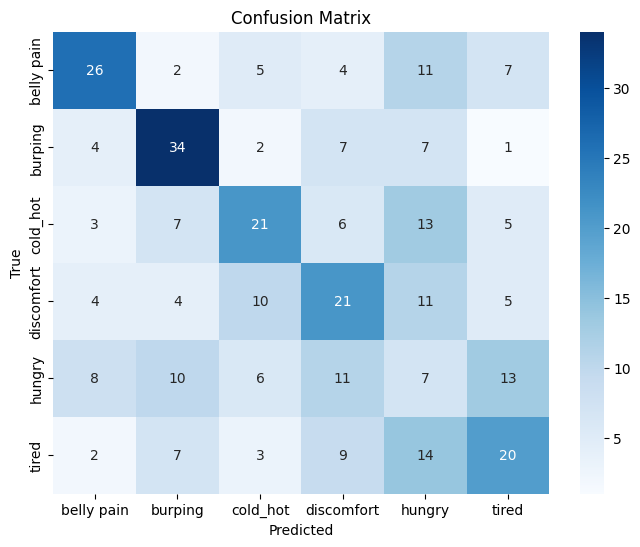


Classification Report:
              precision    recall  f1-score   support

  belly pain       0.55      0.47      0.51        55
     burping       0.53      0.62      0.57        55
    cold_hot       0.45      0.38      0.41        55
  discomfort       0.36      0.38      0.37        55
      hungry       0.11      0.13      0.12        55
       tired       0.39      0.36      0.38        55

    accuracy                           0.39       330
   macro avg       0.40      0.39      0.39       330
weighted avg       0.40      0.39      0.39       330



In [40]:
y_pred = model.predict(X_test)
y_pred_cls = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_cls)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_cls,
    target_names=label_encoder.classes_
))


In [41]:
model = load_model("entropy_dtw_bilstm_model.h5")

sample = np.load(
    r"D:\Infant Cry Vocalisation\Entropy_DTW_features\hungry\sample_features.npy"
)

sample = sample.T
sample = (sample - sample.mean(axis=0)) / (sample.std(axis=0) + 1e-8)

sample = np.expand_dims(sample, axis=0)
sample = pad_sequences(
    sample,
    maxlen=max_len,
    padding="post",
    dtype="float32"
)

pred = model.predict(sample)
pred_class = label_encoder.inverse_transform([np.argmax(pred)])

print(f"Predicted: {pred_class[0]}")
print(f"Confidence: {np.max(pred) * 100:.2f}%")


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Infant Cry Vocalisation\\Entropy_DTW_features\\hungry\\sample_features.npy'